<a href="https://colab.research.google.com/github/SANGHATI23/sam-brats-robustness-audit/blob/main/05_MedReasoner_Counterfactual_Replication_Phi35Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Runtime
import sys, platform, torch
print("Python:",sys.version.split()[0])
print("Platform:",platform.platform())
print("PyTorch:",torch.__version__)
print("CUDA:",torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("GPU runtime required.")
print("GPU:",torch.cuda.get_device_name(0))
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 79.3 GB


In [2]:
# CELL 2 — Phi dependencies only
import subprocess, sys
packages=[
    "transformers==4.43.4",
    "accelerate>=0.33.0,<1",
    "einops>=0.8.0",
    "timm>=1.0.9"
]
subprocess.run([sys.executable,"-m","pip","install","-q","--upgrade",*packages],check=True)
print("Phi dependencies installed.")

Phi dependencies installed.


In [3]:
# CELL 3 — Imports/config
import os,re,json,time,random,gc
from pathlib import Path
from datetime import datetime,timezone
import numpy as np, pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display
import torch, matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,balanced_accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,average_precision_score,brier_score_loss,confusion_matrix,roc_curve
)
from scipy.stats import spearmanr,binomtest
from transformers import AutoModelForCausalLM,AutoProcessor

SEED=2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

MODEL_ID="microsoft/Phi-3.5-vision-instruct"
EXPERIMENT_ID="05_counterfactual_qc_phi35vision"
PROMPT_VERSION="counterfactual_v1.0_matched_to_notebook04"
NUM_CROPS=16
MAX_NEW_TOKENS=180
OVERWRITE_EXISTING=False

DOMAIN_TARGET={
    "brain_mri":{"domain_text":"brain MRI","target_text":"brain tumor"},
    "kidney_ct":{"domain_text":"kidney CT","target_text":"kidney tumor"},
    "histopathology":{"domain_text":"H&E histopathology","target_text":"cell nuclei"}
}
print(MODEL_ID)

microsoft/Phi-3.5-vision-instruct


In [4]:
# CELL 4 — Drive + Notebook-04 benchmark
from google.colab import drive
DRIVE=Path("/content/drive")
if not (DRIVE/"MyDrive").exists():
    drive.mount(str(DRIVE),force_remount=False)

ROOT=DRIVE/"MyDrive"/"MedReasoner_SAM_2026"
CF_ROOT=ROOT/"04_counterfactual_masks"
OUTPUT_DIR=ROOT/"03_vlm_outputs"
EVAL_DIR=ROOT/"05_evaluation"
FIG_DIR=ROOT/"06_figures"
LOG_DIR=ROOT/"logs"
for p in [OUTPUT_DIR,EVAL_DIR,FIG_DIR,LOG_DIR]:
    p.mkdir(parents=True,exist_ok=True)

CF_LABELS_PATH=CF_ROOT/"counterfactual_hidden_labels.csv"
cf=pd.read_csv(CF_LABELS_PATH)

if len(cf)!=270:
    raise ValueError(f"Expected 270 cases, found {len(cf)}")

missing=[p for p in cf["vlm_overlay_path"].astype(str) if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"{len(missing)} overlay images missing.")

print("Cases:",len(cf))
display(cf.groupby(["domain","condition"]).size().reset_index(name="n"))

Mounted at /content/drive
Cases: 270


,domain,condition,n
0,brain_mri,CLEAN,15
1,brain_mri,OVERSEGMENTATION,15
2,brain_mri,PARTIAL_MISSING,15
3,brain_mri,SHIFT,15
4,brain_mri,UNDERSEGMENTATION,15
5,brain_mri,WRONG_REGION,15
6,histopathology,CLEAN,15
7,histopathology,OVERSEGMENTATION,15
8,histopathology,PARTIAL_MISSING,15
9,histopathology,SHIFT,15


In [5]:
# CELL 5 — Blinded manifest
blind=cf[["cf_id","domain","vlm_overlay_path"]].copy()
blind["domain_text"]=blind["domain"].map(lambda x:DOMAIN_TARGET[x]["domain_text"])
blind["target_text"]=blind["domain"].map(lambda x:DOMAIN_TARGET[x]["target_text"])
blind=blind.sample(frac=1.0,random_state=SEED).reset_index(drop=True)

hidden=cf[[
    "cf_id","domain","base_id","condition","is_corrupted","reference_dice",
    "reference_iou","dice_degradation","area_ratio_vs_reference"
]].copy()

BLIND_PATH=OUTPUT_DIR/f"{EXPERIMENT_ID}_blinded_manifest.csv"
blind.to_csv(BLIND_PATH,index=False)
print("Blinded:",len(blind))
display(blind.head())

Blinded: 270


,cf_id,domain,vlm_overlay_path,domain_text,target_text
0,CF_0075,brain_mri,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,brain MRI,brain tumor
1,CF_0132,kidney_ct,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,kidney CT,kidney tumor
2,CF_0259,histopathology,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,H&E histopathology,cell nuclei
3,CF_0184,histopathology,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,H&E histopathology,cell nuclei
4,CF_0197,histopathology,/content/drive/MyDrive/MedReasoner_SAM_2026/04...,H&E histopathology,cell nuclei


In [6]:
# CELL 6 — Matched prompt
def build_prompt(domain_text,target_text):
    return f"""
You are performing quality control of a candidate medical-image segmentation.

Image domain: {domain_text}
Intended segmentation target: {target_text}

The RED overlay/outline is the candidate segmentation.
Judge only the visible relationship between the red segmentation and the medical image.

First decide whether the candidate segmentation is CLEAN or CORRUPTED.

If it is corrupted, identify the single best visible error type from:
- SHIFT
- OVERSEGMENTATION
- UNDERSEGMENTATION
- PARTIAL_MISSING
- WRONG_REGION
- OTHER

Return ONLY one valid JSON object with exactly these fields:
{{
  "qc_label": "CLEAN|CORRUPTED",
  "corruption_probability": 0,
  "error_type": "NONE|SHIFT|OVERSEGMENTATION|UNDERSEGMENTATION|PARTIAL_MISSING|WRONG_REGION|OTHER",
  "grounding": "one concise sentence describing the visible image-mask relationship"
}}

Rules:
- corruption_probability must be an integer from 0 to 100.
- If qc_label is CLEAN, error_type must be NONE.
- If qc_label is CORRUPTED, error_type must not be NONE.
- Do not give a diagnosis.
- Do not discuss Dice, IoU, ground truth, or unseen information.
- grounding must be no more than 35 words.
- Output JSON only; no markdown.
""".strip()

print(build_prompt("brain MRI","brain tumor"))

You are performing quality control of a candidate medical-image segmentation.

Image domain: brain MRI
Intended segmentation target: brain tumor

The RED overlay/outline is the candidate segmentation.
Judge only the visible relationship between the red segmentation and the medical image.

First decide whether the candidate segmentation is CLEAN or CORRUPTED.

If it is corrupted, identify the single best visible error type from:
- SHIFT
- OVERSEGMENTATION
- UNDERSEGMENTATION
- PARTIAL_MISSING
- WRONG_REGION
- OTHER

Return ONLY one valid JSON object with exactly these fields:
{
  "qc_label": "CLEAN|CORRUPTED",
  "corruption_probability": 0,
  "error_type": "NONE|SHIFT|OVERSEGMENTATION|UNDERSEGMENTATION|PARTIAL_MISSING|WRONG_REGION|OTHER",
  "grounding": "one concise sentence describing the visible image-mask relationship"
}

Rules:
- corruption_probability must be an integer from 0 to 100.
- If qc_label is CLEAN, error_type must be NONE.
- If qc_label is CORRUPTED, error_type must not b

In [7]:
# CELL 7 — Load Phi-3.5-Vision
print("Loading:",MODEL_ID)
t0=time.time()
model=AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="cuda",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    _attn_implementation="eager"
)
processor=AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    num_crops=NUM_CROPS
)
model.eval()
print(f"Loaded in {(time.time()-t0)/60:.1f} min")
print("Commit:",getattr(model.config,"_commit_hash",None))

Loading: microsoft/Phi-3.5-vision-instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_phi3_v.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-vision-instruct:
- configuration_phi3_v.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

preprocessor_config.json:   0%|          | 0.00/442 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

Loaded in 0.7 min
Commit: 12b77fb40b63a2c73c68243d3f767aab688a1b2a


In [8]:
# CELL 8 — Parser
ALLOWED_QC={"CLEAN","CORRUPTED"}
ALLOWED_TYPES={"NONE","SHIFT","OVERSEGMENTATION","UNDERSEGMENTATION","PARTIAL_MISSING","WRONG_REGION","OTHER"}

def extract_json(text):
    text=str(text).strip()
    text=re.sub(r"^```(?:json)?\s*","",text,flags=re.I)
    text=re.sub(r"\s*```$","",text)
    try:
        x=json.loads(text)
        if isinstance(x,dict): return x
    except: pass
    m=re.search(r"\{.*\}",text,flags=re.S)
    if m:
        try:
            x=json.loads(m.group(0))
            if isinstance(x,dict): return x
        except: pass
    return None

def normalize(raw):
    obj=extract_json(raw)
    out={"parse_ok":False,"qc_label":None,"corruption_probability":np.nan,"error_type":None,"grounding":None}
    if obj is None: return out
    qc=str(obj.get("qc_label","")).strip().upper()
    et=str(obj.get("error_type","")).strip().upper()
    g=str(obj.get("grounding","")).strip()
    try: p=int(round(float(obj.get("corruption_probability"))))
    except: p=None
    if qc not in ALLOWED_QC or et not in ALLOWED_TYPES or p is None or not(0<=p<=100) or not g:
        return out
    if qc=="CLEAN" and et!="NONE": return out
    if qc=="CORRUPTED" and et=="NONE": return out
    out.update({"parse_ok":True,"qc_label":qc,"corruption_probability":p,"error_type":et,"grounding":g})
    return out

In [9]:
# CELL 9 — Single-case inference
def run_case(row):
    image=Image.open(str(row["vlm_overlay_path"])).convert("RGB")
    task=build_prompt(str(row["domain_text"]),str(row["target_text"]))
    messages=[{"role":"user","content":"<|image_1|>\n"+task}]
    prompt=processor.tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=processor(prompt,[image],return_tensors="pt").to("cuda:0")
    t0=time.time()
    with torch.inference_mode():
        ids=model.generate(
            **inputs,
            eos_token_id=processor.tokenizer.eos_token_id,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=0.0,
            use_cache=True
        )
    ids=ids[:,inputs["input_ids"].shape[1]:]
    raw=processor.batch_decode(ids,skip_special_tokens=True,clean_up_tokenization_spaces=False)[0].strip()
    parsed=normalize(raw)
    out={
        "cf_id":str(row["cf_id"]),
        "domain":str(row["domain"]),
        "model_id":MODEL_ID,
        "prompt_version":PROMPT_VERSION,
        "raw_output":raw,
        "parse_ok":bool(parsed["parse_ok"]),
        "qc_label":parsed["qc_label"],
        "corruption_probability":None if pd.isna(parsed["corruption_probability"]) else int(parsed["corruption_probability"]),
        "error_type":parsed["error_type"],
        "grounding":parsed["grounding"],
        "generation_seconds":float(time.time()-t0),
        "timestamp_utc":datetime.now(timezone.utc).isoformat()
    }
    del image,inputs,ids
    return out

In [10]:
# CELL 10 — Smoke test
smoke=run_case(blind.iloc[0])
print(json.dumps(smoke,indent=2))
if not smoke["parse_ok"]:
    raise RuntimeError("Structured output smoke test failed.")

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.


{
  "cf_id": "CF_0075",
  "domain": "brain_mri",
  "model_id": "microsoft/Phi-3.5-vision-instruct",
  "prompt_version": "counterfactual_v1.0_matched_to_notebook04",
  "raw_output": "{\n  \"qc_label\": \"CORRUPTED\",\n  \"corruption_probability\": 100,\n  \"error_type\": \"WRONG_REGION\",\n  \"grounding\": \"The red segmentation encompasses an area that does not correspond to the known location of the brain tumor.\"\n}",
  "parse_ok": true,
  "qc_label": "CORRUPTED",
  "corruption_probability": 100,
  "error_type": "WRONG_REGION",
  "grounding": "The red segmentation encompasses an area that does not correspond to the known location of the brain tumor.",
  "generation_seconds": 6.269309043884277,
  "timestamp_utc": "2026-08-08T04:27:11.709583+00:00"
}


In [11]:
# CELL 11 — Run/resume 270 cases
PRED_JSONL=OUTPUT_DIR/f"{EXPERIMENT_ID}_predictions.jsonl"

def completed(path):
    s=set()
    if not Path(path).exists(): return s
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            try:s.add(str(json.loads(line)["cf_id"]))
            except:pass
    return s

if OVERWRITE_EXISTING and PRED_JSONL.exists():
    PRED_JSONL.unlink()

done=completed(PRED_JSONL)
errors=[]
print("Previously completed:",len(done))

for i,(_,row) in enumerate(tqdm(blind.iterrows(),total=len(blind),desc="Phi counterfactual QC"),start=1):
    cid=str(row["cf_id"])
    if cid in done: continue
    try:
        r=run_case(row)
        with open(PRED_JSONL,"a",encoding="utf-8") as f:
            f.write(json.dumps(r,ensure_ascii=False)+"\n"); f.flush()
        done.add(cid)
    except Exception as e:
        errors.append({"cf_id":cid,"domain":row["domain"],"error":repr(e)})
    if i%10==0:
        gc.collect(); torch.cuda.empty_cache()

print("Completed:",len(done),"Errors:",len(errors))
if errors:
    edf=pd.DataFrame(errors); display(edf)
    edf.to_csv(LOG_DIR/f"{EXPERIMENT_ID}_runtime_errors.csv",index=False)

Previously completed: 0


Phi counterfactual QC:   0%|          | 0/270 [00:00<?, ?it/s]

Completed: 270 Errors: 0


In [12]:
# CELL 12 — Prediction inventory + labels
rows=[]
with open(PRED_JSONL,"r",encoding="utf-8") as f:
    for line in f:
        if line.strip(): rows.append(json.loads(line))

pred=pd.DataFrame(rows).sort_values("timestamp_utc").drop_duplicates("cf_id",keep="last")
pred=pred[pred["cf_id"].isin(blind["cf_id"])].copy()
PRED_CSV=OUTPUT_DIR/f"{EXPERIMENT_ID}_predictions.csv"
pred.to_csv(PRED_CSV,index=False)

ev=pred.merge(hidden,on=["cf_id","domain"],how="inner",validate="one_to_one")
valid=ev[ev["parse_ok"]==True].copy()
valid["pred_corrupted"]=valid["qc_label"]=="CORRUPTED"
valid["corruption_score"]=pd.to_numeric(valid["corruption_probability"],errors="coerce")/100.0
valid["true_error_type"]=valid["condition"].replace({"CLEAN":"NONE"})

CASE_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_case_level_evaluation.csv"
valid.to_csv(CASE_PATH,index=False)

print("Unique:",len(pred),"/",len(blind))
print("Parse success:",f"{pred['parse_ok'].mean()*100:.1f}%")
print("Evaluable:",len(valid))
display(pred["qc_label"].value_counts(dropna=False).rename_axis("qc_label").reset_index(name="n"))
display(pred["error_type"].value_counts(dropna=False).rename_axis("error_type").reset_index(name="n"))

Unique: 270 / 270
Parse success: 94.1%
Evaluable: 254


,qc_label,n
0,CORRUPTED,241
1,None,16
2,CLEAN,13


,error_type,n
0,WRONG_REGION,144
1,OVERSEGMENTATION,68
2,SHIFT,25
3,None,16
4,NONE,13
5,PARTIAL_MISSING,4


In [13]:
# CELL 13 — Metrics
def binary_metrics(df):
    y=df["is_corrupted"].astype(int).to_numpy()
    p=df["pred_corrupted"].astype(int).to_numpy()
    s=df["corruption_score"].astype(float).to_numpy()
    tn,fp,fn,tp=confusion_matrix(y,p,labels=[0,1]).ravel()
    out={
        "n":int(len(df)),
        "accuracy":float(accuracy_score(y,p)),
        "balanced_accuracy":float(balanced_accuracy_score(y,p)),
        "precision":float(precision_score(y,p,zero_division=0)),
        "sensitivity":float(recall_score(y,p,zero_division=0)),
        "specificity":float(tn/(tn+fp)) if tn+fp else np.nan,
        "f1":float(f1_score(y,p,zero_division=0)),
        "false_reassurance_rate":float(fn/(fn+tp)) if fn+tp else np.nan,
        "false_alarm_rate":float(fp/(fp+tn)) if fp+tn else np.nan,
        "tp":int(tp),"tn":int(tn),"fp":int(fp),"fn":int(fn)
    }
    if len(np.unique(y))==2 and np.isfinite(s).all():
        out.update({
            "auroc":float(roc_auc_score(y,s)),
            "auprc":float(average_precision_score(y,s)),
            "brier":float(brier_score_loss(y,s))
        })
    else:
        out.update({"auroc":np.nan,"auprc":np.nan,"brier":np.nan})
    return out

phi=binary_metrics(valid)

TYPE_LABELS=["NONE","SHIFT","OVERSEGMENTATION","UNDERSEGMENTATION","PARTIAL_MISSING","WRONG_REGION","OTHER"]
type_acc=float(accuracy_score(valid["true_error_type"],valid["error_type"]))
type_f1=float(f1_score(valid["true_error_type"],valid["error_type"],labels=TYPE_LABELS,average="macro",zero_division=0))

corr=valid[valid["is_corrupted"]==True]
corr_type_acc=float(accuracy_score(corr["condition"],corr["error_type"]))
corr_type_f1=float(f1_score(corr["condition"],corr["error_type"],
    labels=["SHIFT","OVERSEGMENTATION","UNDERSEGMENTATION","PARTIAL_MISSING","WRONG_REGION"],
    average="macro",zero_division=0))

display(pd.DataFrame([phi]))
display(pd.DataFrame([{
    "all_case_error_type_accuracy":type_acc,
    "all_case_error_type_macro_f1":type_f1,
    "corrupted_only_type_accuracy":corr_type_acc,
    "corrupted_only_type_macro_f1":corr_type_f1
}]))

,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier
0,254,0.818898,0.539182,0.842324,0.962085,0.116279,0.89823,0.037915,0.883721,203,5,38,8,0.52772,0.838475,0.173868


,all_case_error_type_accuracy,all_case_error_type_macro_f1,corrupted_only_type_accuracy,corrupted_only_type_macro_f1
0,0.086614,0.058569,0.080569,0.052044


In [14]:
# CELL 14 — Per-condition, domain, association
condition_rows=[]
for condition,ddf in valid.groupby("condition"):
    if condition=="CLEAN":
        binary_correct=float((ddf["qc_label"]=="CLEAN").mean())
        type_correct=float((ddf["error_type"]=="NONE").mean())
    else:
        binary_correct=float(ddf["pred_corrupted"].mean())
        type_correct=float((ddf["error_type"]==condition).mean())
    condition_rows.append({
        "condition":condition,
        "n":len(ddf),
        "mean_reference_dice":float(ddf["reference_dice"].mean()),
        "mean_corruption_probability":float(ddf["corruption_score"].mean()),
        "correct_binary_qc_rate":binary_correct,
        "correct_error_type_rate":type_correct
    })
condition_metrics=pd.DataFrame(condition_rows)
COND_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_condition_metrics.csv"
condition_metrics.to_csv(COND_PATH,index=False)

domain_rows=[]
for domain,ddf in valid.groupby("domain"):
    m=binary_metrics(ddf); m["domain"]=domain
    domain_rows.append(m)
domain_metrics=pd.DataFrame(domain_rows)
DOMAIN_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_domain_metrics.csv"
domain_metrics.to_csv(DOMAIN_PATH,index=False)

rho,rho_p=spearmanr(valid["corruption_score"],valid["dice_degradation"],nan_policy="omit")
display(condition_metrics.sort_values("condition"))
display(domain_metrics)
display(pd.DataFrame([{"spearman_rho":rho,"p_value":rho_p}]))

,condition,n,mean_reference_dice,mean_corruption_probability,correct_binary_qc_rate,correct_error_type_rate
0,CLEAN,43,1.000000,0.858140,0.116279,0.116279
1,OVERSEGMENTATION,41,0.529230,0.947561,0.975610,0.097561
2,PARTIAL_MISSING,43,0.571383,0.967442,1.000000,0.000000
3,SHIFT,44,0.077840,0.945455,0.977273,0.022727
4,UNDERSEGMENTATION,41,0.586540,0.828049,0.853659,0.000000
5,WRONG_REGION,42,0.066826,0.972619,1.000000,0.285714


,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier,domain
0,90,0.833333,0.500000,0.833333,1.000000,0.000000,0.909091,0.000000,1.000000,75,0,15,0,0.533333,0.842713,0.163694,brain_mri
1,88,0.795455,0.611872,0.866667,0.890411,0.333333,0.878378,0.109589,0.666667,65,5,10,8,0.605023,0.860315,0.196278,histopathology
2,76,0.828947,0.500000,0.828947,1.000000,0.000000,0.906475,0.000000,1.000000,63,0,13,0,0.463980,0.819469,0.159967,kidney_ct


,spearman_rho,p_value
0,0.085902,0.172307


In [15]:
# CELL 15 — Bootstrap 95% CI
def boot_ci(df,metric,n_boot=2000):
    rng=np.random.default_rng(SEED); vals=[]; n=len(df)
    for _ in range(n_boot):
        b=df.iloc[rng.integers(0,n,size=n)]
        try:
            v=binary_metrics(b)[metric]
            if np.isfinite(v): vals.append(v)
        except: pass
    return (float(np.percentile(vals,2.5)),float(np.percentile(vals,97.5))) if vals else (np.nan,np.nan)

ci=[]
for metric in ["balanced_accuracy","sensitivity","specificity","f1","false_reassurance_rate","false_alarm_rate","auroc","auprc","brier"]:
    lo,hi=boot_ci(valid,metric)
    ci.append({"metric":metric,"estimate":phi[metric],"ci95_low":lo,"ci95_high":hi})
ci=pd.DataFrame(ci)
CI_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_bootstrap_95ci.csv"
ci.to_csv(CI_PATH,index=False)
display(ci)

,metric,estimate,ci95_low,ci95_high
0,balanced_accuracy,0.539182,0.493514,0.593738
1,sensitivity,0.962085,0.934884,0.985579
2,specificity,0.116279,0.025000,0.222292
3,f1,0.898230,0.869945,0.926006
4,false_reassurance_rate,0.037915,0.014421,0.065116
5,false_alarm_rate,0.883721,0.777708,0.975000
6,auroc,0.527720,0.441610,0.616544
7,auprc,0.838475,0.790069,0.889524
8,brier,0.173868,0.128956,0.216686


In [16]:
# CELL 16 — Load Qwen Notebook-04 results
QWEN_PATH=EVAL_DIR/"04_counterfactual_qc_qwen25vl7b_case_level_evaluation.csv"
qwen=pd.read_csv(QWEN_PATH)

for col in ["is_corrupted","pred_corrupted"]:
    if qwen[col].dtype==object:
        qwen[col]=qwen[col].astype(str).str.lower().map({"true":True,"false":False})
if "corruption_score" not in qwen.columns:
    qwen["corruption_score"]=pd.to_numeric(qwen["corruption_probability"],errors="coerce")/100.0

qwen_m=binary_metrics(qwen)
q_type_acc=float(accuracy_score(qwen["true_error_type"],qwen["error_type"]))
q_corr=qwen[qwen["is_corrupted"]==True]
q_corr_type_acc=float(accuracy_score(q_corr["condition"],q_corr["error_type"]))

comparison=pd.DataFrame([
    {"model":"Qwen2.5-VL-7B-Instruct",**{k:qwen_m[k] for k in ["balanced_accuracy","sensitivity","specificity","f1","false_reassurance_rate","false_alarm_rate","auroc","auprc","brier"]},
     "all_case_error_type_accuracy":q_type_acc,"corrupted_only_type_accuracy":q_corr_type_acc},
    {"model":"Phi-3.5-Vision-Instruct",**{k:phi[k] for k in ["balanced_accuracy","sensitivity","specificity","f1","false_reassurance_rate","false_alarm_rate","auroc","auprc","brier"]},
     "all_case_error_type_accuracy":type_acc,"corrupted_only_type_accuracy":corr_type_acc}
])
COMPARE_PATH=EVAL_DIR/"05_counterfactual_qwen_vs_phi_model_comparison.csv"
comparison.to_csv(COMPARE_PATH,index=False)
display(comparison)

,model,balanced_accuracy,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,auroc,auprc,brier,all_case_error_type_accuracy,corrupted_only_type_accuracy
0,Qwen2.5-VL-7B-Instruct,0.604444,0.897778,0.311111,0.882096,0.102222,0.688889,0.604444,0.863516,0.208778,0.237037,0.222222
1,Phi-3.5-Vision-Instruct,0.539182,0.962085,0.116279,0.898230,0.037915,0.883721,0.527720,0.838475,0.173868,0.086614,0.080569


In [17]:
# CELL 17 — Paired McNemar + paired bootstrap
qsmall=qwen[["cf_id","is_corrupted","pred_corrupted","corruption_probability","condition","error_type"]].rename(
    columns={"pred_corrupted":"qwen_pred","corruption_probability":"qwen_prob","error_type":"qwen_type"})
psmall=valid[["cf_id","is_corrupted","pred_corrupted","corruption_probability","condition","error_type"]].rename(
    columns={"pred_corrupted":"phi_pred","corruption_probability":"phi_prob","error_type":"phi_type"})
paired=psmall.merge(qsmall,on=["cf_id","is_corrupted","condition"],validate="one_to_one")

paired["qwen_correct"]=paired["qwen_pred"]==paired["is_corrupted"]
paired["phi_correct"]=paired["phi_pred"]==paired["is_corrupted"]
paired["qwen_score"]=pd.to_numeric(paired["qwen_prob"])/100.0
paired["phi_score"]=pd.to_numeric(paired["phi_prob"])/100.0

b=int((paired["qwen_correct"] & ~paired["phi_correct"]).sum())
c=int((~paired["qwen_correct"] & paired["phi_correct"]).sum())
mcnemar_p=float(binomtest(min(b,c),n=b+c,p=.5).pvalue) if b+c else 1.0
mcnemar=pd.DataFrame([{"paired_n":len(paired),"qwen_correct_phi_wrong":b,"qwen_wrong_phi_correct":c,"exact_mcnemar_p":mcnemar_p}])
display(mcnemar)

def paired_boot(metric,n_boot=5000):
    rng=np.random.default_rng(SEED); ds=[]; n=len(paired)
    for _ in range(n_boot):
        d=paired.iloc[rng.integers(0,n,size=n)]
        y=d["is_corrupted"].astype(int)
        if metric=="balanced_accuracy":
            q=balanced_accuracy_score(y,d["qwen_pred"].astype(int))
            p=balanced_accuracy_score(y,d["phi_pred"].astype(int))
        else:
            if len(np.unique(y))<2: continue
            q=roc_auc_score(y,d["qwen_score"])
            p=roc_auc_score(y,d["phi_score"])
        ds.append(p-q)
    a=np.asarray(ds)
    return {"metric":metric,"difference_phi_minus_qwen":float(a.mean()),"ci95_low":float(np.percentile(a,2.5)),
            "ci95_high":float(np.percentile(a,97.5)),"bootstrap_probability_phi_gt_qwen":float((a>0).mean())}

paired_diff=pd.DataFrame([paired_boot("balanced_accuracy"),paired_boot("auroc")])
display(paired_diff)

mcnemar.to_csv(EVAL_DIR/"05_counterfactual_qwen_vs_phi_exact_mcnemar.csv",index=False)
paired_diff.to_csv(EVAL_DIR/"05_counterfactual_qwen_vs_phi_paired_bootstrap.csv",index=False)

,paired_n,qwen_correct_phi_wrong,qwen_wrong_phi_correct,exact_mcnemar_p
0,254,10,16,0.32694


,metric,difference_phi_minus_qwen,ci95_low,ci95_high,bootstrap_probability_phi_gt_qwen
0,balanced_accuracy,-0.068987,-0.141765,0.001074,0.0272
1,auroc,-0.080849,-0.163839,0.000900,0.0268


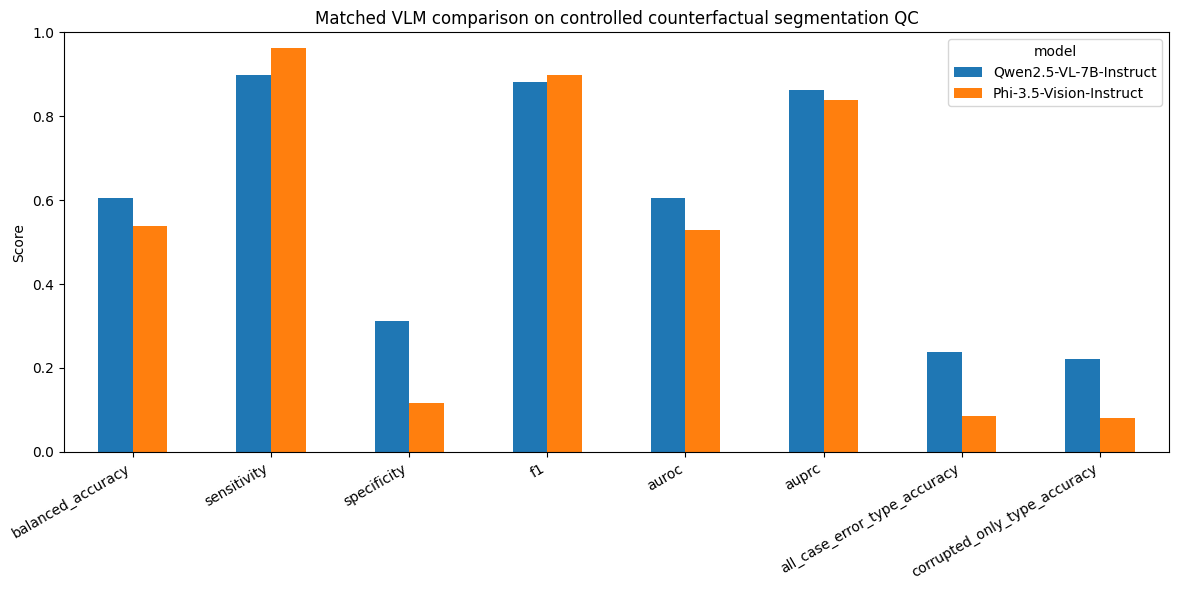

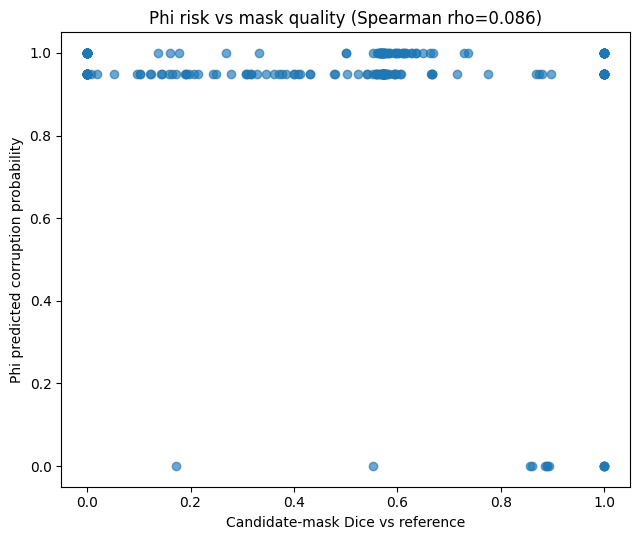

In [18]:
# CELL 18 — Comparison figures
plot_cols=["balanced_accuracy","sensitivity","specificity","f1","auroc","auprc","all_case_error_type_accuracy","corrupted_only_type_accuracy"]
ax=comparison[["model"]+plot_cols].set_index("model").T.plot(kind="bar",figsize=(12,6))
ax.set_ylim(0,1); ax.set_ylabel("Score"); ax.set_xlabel("")
ax.set_title("Matched VLM comparison on controlled counterfactual segmentation QC")
plt.xticks(rotation=30,ha="right"); plt.tight_layout()
FIG=FIG_DIR/"05_counterfactual_qwen_vs_phi_comparison.png"
plt.savefig(FIG,dpi=220,bbox_inches="tight"); plt.show()

fig,ax=plt.subplots(figsize=(6.5,5.5))
ax.scatter(valid["reference_dice"],valid["corruption_score"],alpha=.65)
ax.set_xlabel("Candidate-mask Dice vs reference")
ax.set_ylabel("Phi predicted corruption probability")
ax.set_title(f"Phi risk vs mask quality (Spearman rho={rho:.3f})")
plt.tight_layout()
RISK_FIG=FIG_DIR/f"{EXPERIMENT_ID}_risk_vs_reference_dice.png"
plt.savefig(RISK_FIG,dpi=220,bbox_inches="tight"); plt.show()

In [19]:
# CELL 19 — Final results summary
summary={
    "experiment_id":EXPERIMENT_ID,
    "model_id":MODEL_ID,
    "model_commit":getattr(model.config,"_commit_hash",None),
    "prompt_version":PROMPT_VERSION,
    "benchmark_cases":int(len(blind)),
    "evaluable_cases":int(len(valid)),
    "parse_success_rate":float(pred["parse_ok"].mean()),
    "phi_primary_binary_metrics":phi,
    "phi_error_type_metrics":{
        "all_case_accuracy":type_acc,
        "all_case_macro_f1":type_f1,
        "corrupted_only_accuracy":corr_type_acc,
        "corrupted_only_macro_f1":corr_type_f1
    },
    "phi_risk_severity_association":{"spearman_rho":float(rho),"p_value":float(rho_p)},
    "paired_qwen_vs_phi":{"paired_n":int(len(paired)),"exact_mcnemar_p":float(mcnemar_p)},
    "mean_generation_seconds":float(pred["generation_seconds"].mean())
}
SUMMARY_PATH=EVAL_DIR/f"{EXPERIMENT_ID}_summary.json"
SUMMARY_PATH.write_text(json.dumps(summary,indent=2))

print("="*88)
print("COUNTERFACTUAL REPLICATION RESULTS — PHI-3.5-VISION")
print("="*88)
print(f"Evaluable cases: {len(valid)} / {len(blind)}")
print(f"Parse success: {pred['parse_ok'].mean()*100:.1f}%")
print()
print("Phi CLEAN vs CORRUPTED")
for label,key in [
    ("Balanced accuracy","balanced_accuracy"),("Sensitivity","sensitivity"),("Specificity","specificity"),
    ("F1","f1"),("False reassurance","false_reassurance_rate"),("False alarm rate","false_alarm_rate"),
    ("AUROC","auroc"),("AUPRC","auprc"),("Brier score","brier")
]:
    print(f"  {label:18s}: {phi[key]:.3f}")
print()
print("Phi error-type identification")
print(f"  All-case accuracy       : {type_acc:.3f}")
print(f"  All-case macro F1       : {type_f1:.3f}")
print(f"  Corrupted-only accuracy : {corr_type_acc:.3f}")
print(f"  Corrupted-only macro F1 : {corr_type_f1:.3f}")
print()
print("Phi risk vs Dice degradation")
print(f"  Spearman rho : {rho:.3f}")
print(f"  p-value      : {rho_p:.3g}")
print()
print("Matched Qwen vs Phi")
display(comparison)
print("Paired bootstrap differences")
display(paired_diff)
print("Exact McNemar")
display(mcnemar)
print("Per-condition Phi")
display(condition_metrics.sort_values("condition"))
print("Per-domain Phi")
display(domain_metrics)
print("Summary saved:",SUMMARY_PATH)

COUNTERFACTUAL REPLICATION RESULTS — PHI-3.5-VISION
Evaluable cases: 254 / 270
Parse success: 94.1%

Phi CLEAN vs CORRUPTED
  Balanced accuracy : 0.539
  Sensitivity       : 0.962
  Specificity       : 0.116
  F1                : 0.898
  False reassurance : 0.038
  False alarm rate  : 0.884
  AUROC             : 0.528
  AUPRC             : 0.838
  Brier score       : 0.174

Phi error-type identification
  All-case accuracy       : 0.087
  All-case macro F1       : 0.059
  Corrupted-only accuracy : 0.081
  Corrupted-only macro F1 : 0.052

Phi risk vs Dice degradation
  Spearman rho : 0.086
  p-value      : 0.172

Matched Qwen vs Phi


,model,balanced_accuracy,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,auroc,auprc,brier,all_case_error_type_accuracy,corrupted_only_type_accuracy
0,Qwen2.5-VL-7B-Instruct,0.604444,0.897778,0.311111,0.882096,0.102222,0.688889,0.604444,0.863516,0.208778,0.237037,0.222222
1,Phi-3.5-Vision-Instruct,0.539182,0.962085,0.116279,0.898230,0.037915,0.883721,0.527720,0.838475,0.173868,0.086614,0.080569


Paired bootstrap differences


,metric,difference_phi_minus_qwen,ci95_low,ci95_high,bootstrap_probability_phi_gt_qwen
0,balanced_accuracy,-0.068987,-0.141765,0.001074,0.0272
1,auroc,-0.080849,-0.163839,0.000900,0.0268


Exact McNemar


...

Per-condition Phi


,condition,n,mean_reference_dice,mean_corruption_probability,correct_binary_qc_rate,correct_error_type_rate
0,CLEAN,43,1.000000,0.858140,0.116279,0.116279
1,OVERSEGMENTATION,41,0.529230,0.947561,0.975610,0.097561
2,PARTIAL_MISSING,43,0.571383,0.967442,1.000000,0.000000
3,SHIFT,44,0.077840,0.945455,0.977273,0.022727
4,UNDERSEGMENTATION,41,0.586540,0.828049,0.853659,0.000000
5,WRONG_REGION,42,0.066826,0.972619,1.000000,0.285714


Per-domain Phi


,n,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,false_reassurance_rate,false_alarm_rate,tp,tn,fp,fn,auroc,auprc,brier,domain
0,90,0.833333,0.500000,0.833333,1.000000,0.000000,0.909091,0.000000,1.000000,75,0,15,0,0.533333,0.842713,0.163694,brain_mri
1,88,0.795455,0.611872,0.866667,0.890411,0.333333,0.878378,0.109589,0.666667,65,5,10,8,0.605023,0.860315,0.196278,histopathology
2,76,0.828947,0.500000,0.828947,1.000000,0.000000,0.906475,0.000000,1.000000,63,0,13,0,0.463980,0.819469,0.159967,kidney_ct


Summary saved: /content/drive/MyDrive/MedReasoner_SAM_2026/05_evaluation/05_counterfactual_qc_phi35vision_summary.json
